### This is a simple notebook to build and visualize the kNN algorithm.  
It accompanies Chapter 2 of the book.  
Copyright: Viviana Acquaviva (2023)  
License: [BSD-3-clause](https://opensource.org/license/bsd-3-clause/)  
Modifications by Aaron Romanowsky.

In [123]:
import numpy as np
import matplotlib
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import pandas as pd 
import sklearn
from sklearn import metrics # this will give us access to evaluation metrics
from sklearn import neighbors # here comes the method of the day
import seaborn as sns

In [124]:
font = {'size'   : 20}
matplotlib.rc('font', **font)
matplotlib.rc('xtick', labelsize=20) 
matplotlib.rc('ytick', labelsize=20) 
matplotlib.rcParams['figure.dpi'] = 300
plt.rc('xtick', labelsize=14) 
plt.rc('ytick', labelsize=14) 
plt.rc('xtick.major', size=10, width=1.2)
plt.rc('ytick.major', size=10, width=1.2)
plt.rc('figure', figsize=[12,8])

### Read in data from file

In [125]:
LearningSet = pd.read_csv('HPLearningSet.csv')
LearningSet = LearningSet.drop(LearningSet.columns[0], axis=1) #We want to drop the first column of the file

In [126]:
#By now we know data frames
LearningSet 

,P_NAME,S_MASS,P_PERIOD,P_DISTANCE,P_HABITABLE
0,Kepler-736 b,0.86,3.601472,0.043718,0
1,Kepler-636 b,0.85,16.080661,0.118082,0
2,Kepler-887 c,1.19,7.638460,0.080420,0
3,Kepler-442 b,0.61,112.305300,0.409327,1
4,Kepler-772 b,0.98,12.992073,0.107408,0
5,Teegarden's Star b,0.09,4.910000,0.025200,1
6,K2-116 b,0.69,4.655411,0.048086,0
7,GJ 1061 c,0.12,6.689000,0.035000,1
8,HD 68402 b,1.12,1103.000000,2.180981,0
9,Kepler-1544 b,0.81,168.811170,0.557107,1


### Let's pick the same train/test set we had in the previous exercise.

In [127]:
TrainSet =  LearningSet.iloc[:13,:] #.iloc is used to slice data frames using positional indices
TestSet = LearningSet.iloc[13:,:]

### We split the train and test sets in features and labels.

In [128]:
Xtrain = TrainSet.drop(['P_NAME','P_HABITABLE'],axis=1) #This contains stellar mass, period, and distance
Xtest = TestSet.drop(['P_NAME','P_HABITABLE'],axis=1)  #This contains stellar mass, period, and distance

In [129]:
ytrain = TrainSet.P_HABITABLE #This contains the ground truth label, or output
ytest = TestSet.P_HABITABLE #This contains the ground truth  label, or output

### We are now ready to deploy the kNN ($k$ Nearest Neighbor) algorithm.

It's a simple algorithm based on the idea of distance: we look for the $k$ (an integer) objects that are closest to the one we would like to classify, and take the majority vote among the $k$ classes of the $k$ neighbors.

If you are wondering: what is even there to fit?

I had the same question, and found some solace in [this post](https://stats.stackexchange.com/questions/349842/why-do-we-need-to-fit-a-k-nearest-neighbors-classifier).

In [130]:
knnmodel = neighbors.KNeighborsClassifier(n_neighbors = 7, leaf_size=1000)
# we're using k=3 because our training set is very small

In [131]:
knnmodel

,"n_neighbors n_neighbors: int, default=5Number of neighbors to use by default for :meth:`kneighbors` queries.",7
,"weights weights: {'uniform', 'distance'}, callable or None, default='uniform'Weight function used in prediction. Possible values:- 'uniform' : uniform weights. All points in each neighborhood are weighted equally.- 'distance' : weight points by the inverse of their distance. in this case, closer neighbors of a query point will have a greater influence than neighbors which are further away.- [callable] : a user-defined function which accepts an array of distances, and returns an array of the same shape containing the weights.Refer to the example entitled:ref:`sphx_glr_auto_examples_neighbors_plot_classification.py`showing the impact of the `weights` parameter on the decisionboundary.",'uniform'
,"algorithm algorithm: {'auto', 'ball_tree', 'kd_tree', 'brute'}, default='auto'Algorithm used to compute the nearest neighbors:- 'ball_tree' will use :class:`BallTree`- 'kd_tree' will use :class:`KDTree`- 'brute' will use a brute-force search.- 'auto' will attempt to decide the most appropriate algorithm based on the values passed to :meth:`fit` method.Note: fitting on sparse input will override the setting ofthis parameter, using brute force.",'auto'
,"leaf_size leaf_size: int, default=30Leaf size passed to BallTree or KDTree. This can affect thespeed of the construction and query, as well as the memoryrequired to store the tree. The optimal value depends on thenature of the problem.",1000
,"p p: float, default=2Power parameter for the Minkowski metric. When p = 1, this is equivalentto using manhattan_distance (l1), and euclidean_distance (l2) for p = 2.For arbitrary p, minkowski_distance (l_p) is used. This parameter is expectedto be positive.",2
,"metric metric: str or callable, default='minkowski'Metric to use for distance computation. Default is ""minkowski"", whichresults in the standard Euclidean distance when p = 2. See thedocumentation of `scipy.spatial.distance`_ andthe metrics listed in:class:`~sklearn.metrics.pairwise.distance_metrics` for valid metricvalues.If metric is ""precomputed"", X is assumed to be a distance matrix andmust be square during fit. X may be a :term:`sparse graph`, in whichcase only ""nonzero"" elements may be considered neighbors.If metric is a callable function, it takes two arrays representing 1Dvectors as inputs and must return one value indicating the distancebetween those vectors. This works for Scipy's metrics, but is lessefficient than passing the metric name as a string.",'minkowski'
,"metric_params metric_params: dict, default=NoneAdditional keyword arguments for the metric function.",None
,"n_jobs n_jobs: int, default=NoneThe number of parallel jobs to run for neighbors search.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details.Doesn't affect :meth:`fit` method.",None


### For visualization purposes, let's use only the first two features to build the model.

In [132]:
Xtrain.iloc[:,:2] 

,S_MASS,P_PERIOD
0,0.86,3.601472
1,0.85,16.080661
2,1.19,7.638460
3,0.61,112.305300
4,0.98,12.992073
5,0.09,4.910000
6,0.69,4.655411
7,0.12,6.689000
8,1.12,1103.000000
9,0.81,168.811170


#### Build model by applying the ".fit" method to the training set. Then predict labels for the test set.

In [133]:
# We can chain the fit/predict process like this, or use the fit_predict method
knnmodel.fit(Xtrain.iloc[:,:2],ytrain) #this fits the model, which can then be used to predict labels for new instances
ytestpred = knnmodel.predict(Xtest.iloc[:,:2]) #this uses the fitted model to predict the labels for the 5 objects in test set

In [134]:
ytestpred, ytest.values #compare

(array([1, 0, 1, 0, 1]), array([0, 0, 1, 0, 1]))

#### Calculate accuracy on the train set and on the test set (train score and test score):

In [135]:
print(metrics.accuracy_score(ytrain, knnmodel.predict(Xtrain.iloc[:,:2]))) #This compares the true labels for the train set with the predicted labels for the train set
print(metrics.accuracy_score(ytest, knnmodel.predict(Xtest.iloc[:,:2]))) #This compares the true labels for the test set with the predicted labels for the test set
                                                                      #(same that we did above)  
print(ytrain)
print(knnmodel.predict(Xtrain.iloc[:,:2]))

0.7692307692307693
0.8
0     0
1     0
2     0
3     1
4     0
5     1
6     0
7     1
8     0
9     1
10    1
11    1
12    0
Name: P_HABITABLE, dtype: int64
[0 0 0 1 0 0 0 0 1 1 1 1 0]


make a confusion matrix

In [136]:
#mat = metrics.confusion_matrix(ytrain, knnmodel.predict(Xtrain.iloc[:,:2]))
mat = metrics.confusion_matrix(ytest, ytestpred)

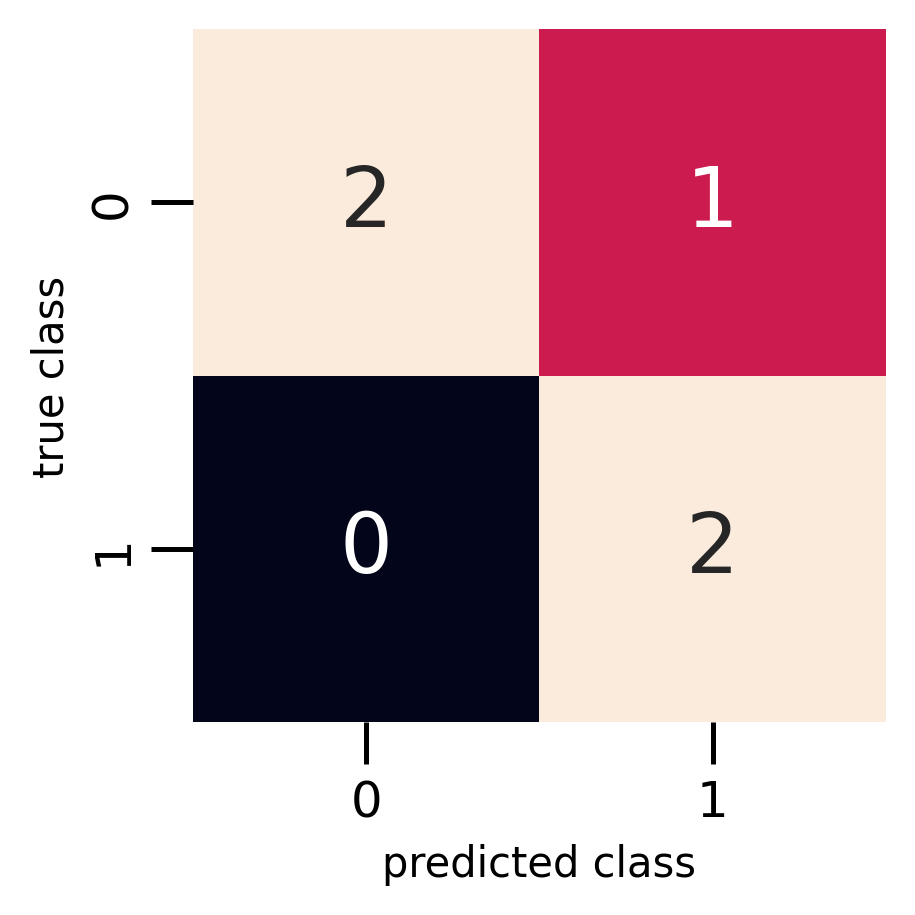

In [137]:
fig1 = plt.figure(figsize=(3,3))
sns.heatmap(mat, square=True, annot=True, cbar=False)
plt.xlabel('predicted class',fontsize=10)
plt.ylabel('true class',fontsize=10)
plt.tick_params(labelsize=12)

#### After fitting and predicting, we can access the $k$ neighbors for each element in the test set like this:

In [138]:
knnmodel.kneighbors(Xtest.iloc[:,:2]) #the first element gives the distances, the second the index of each neighbor

(array([[ 0.26575741, 21.66422235, 39.72600482, 42.8154405 , 48.17091229,
         49.11954488, 50.89875947],
        [ 0.67412717,  2.76390862,  5.76653597,  6.66930799,  8.44806274,
          8.48388925,  8.70109535],
        [ 7.28027781, 29.19416   , 47.25690512, 48.96915355, 50.3464852 ,
         55.70208359, 56.64854454],
        [ 1.807928  ,  2.87670841,  3.5579225 ,  4.61086085,  4.63252119,
          4.78753081,  5.83391279],
        [ 7.9223177 , 13.99261869, 32.05672308, 35.14688856, 40.50335961,
         41.44658575, 43.22575968]]),
 array([[11, 10,  1,  4,  2,  7,  5],
        [ 4,  1,  2,  7,  5, 12,  6],
        [11, 10,  1,  3,  4,  2,  7],
        [ 2,  7,  4,  5, 12,  6,  0],
        [11, 10,  1,  4,  2,  7,  5]]))

### Let's now visualize our results, similarly to what we did for the DT.

We can use the distance of the third neighbor as the radius of the circle that encompasses neighbors.


In [139]:
for i in range(len(TestSet)): # cycle through elements of the test set
    print(knnmodel.kneighbors(Xtest.iloc[:,:2])[0][i,2]) # this prints out the third element of the distances vector

39.7260048163029
5.766535965914375
47.2569051246575
3.557922500000002
32.05672308015779


The following code draws a circle encompassing the 3 nearest neighbors for each data point.  
Note we are cutting off the highest value of period.

C:\Users\Simon Seo\AppData\Local\Temp\ipykernel_28740\514245638.py:4: UserWarning: You passed both c and facecolor/facecolors for the markers. c has precedence over facecolor/facecolors. This behavior may change in the future.
  a = plt.scatter(TrainSet['S_MASS'], TrainSet['P_PERIOD'], marker = '*',facecolor = 'none',\
C:\Users\Simon Seo\AppData\Local\Temp\ipykernel_28740\514245638.py:7: UserWarning: You passed both c and facecolor/facecolors for the markers. c has precedence over facecolor/facecolors. This behavior may change in the future.
  a = plt.scatter(TestSet['S_MASS'], TestSet['P_PERIOD'], marker = 'o',facecolors = 'none',\


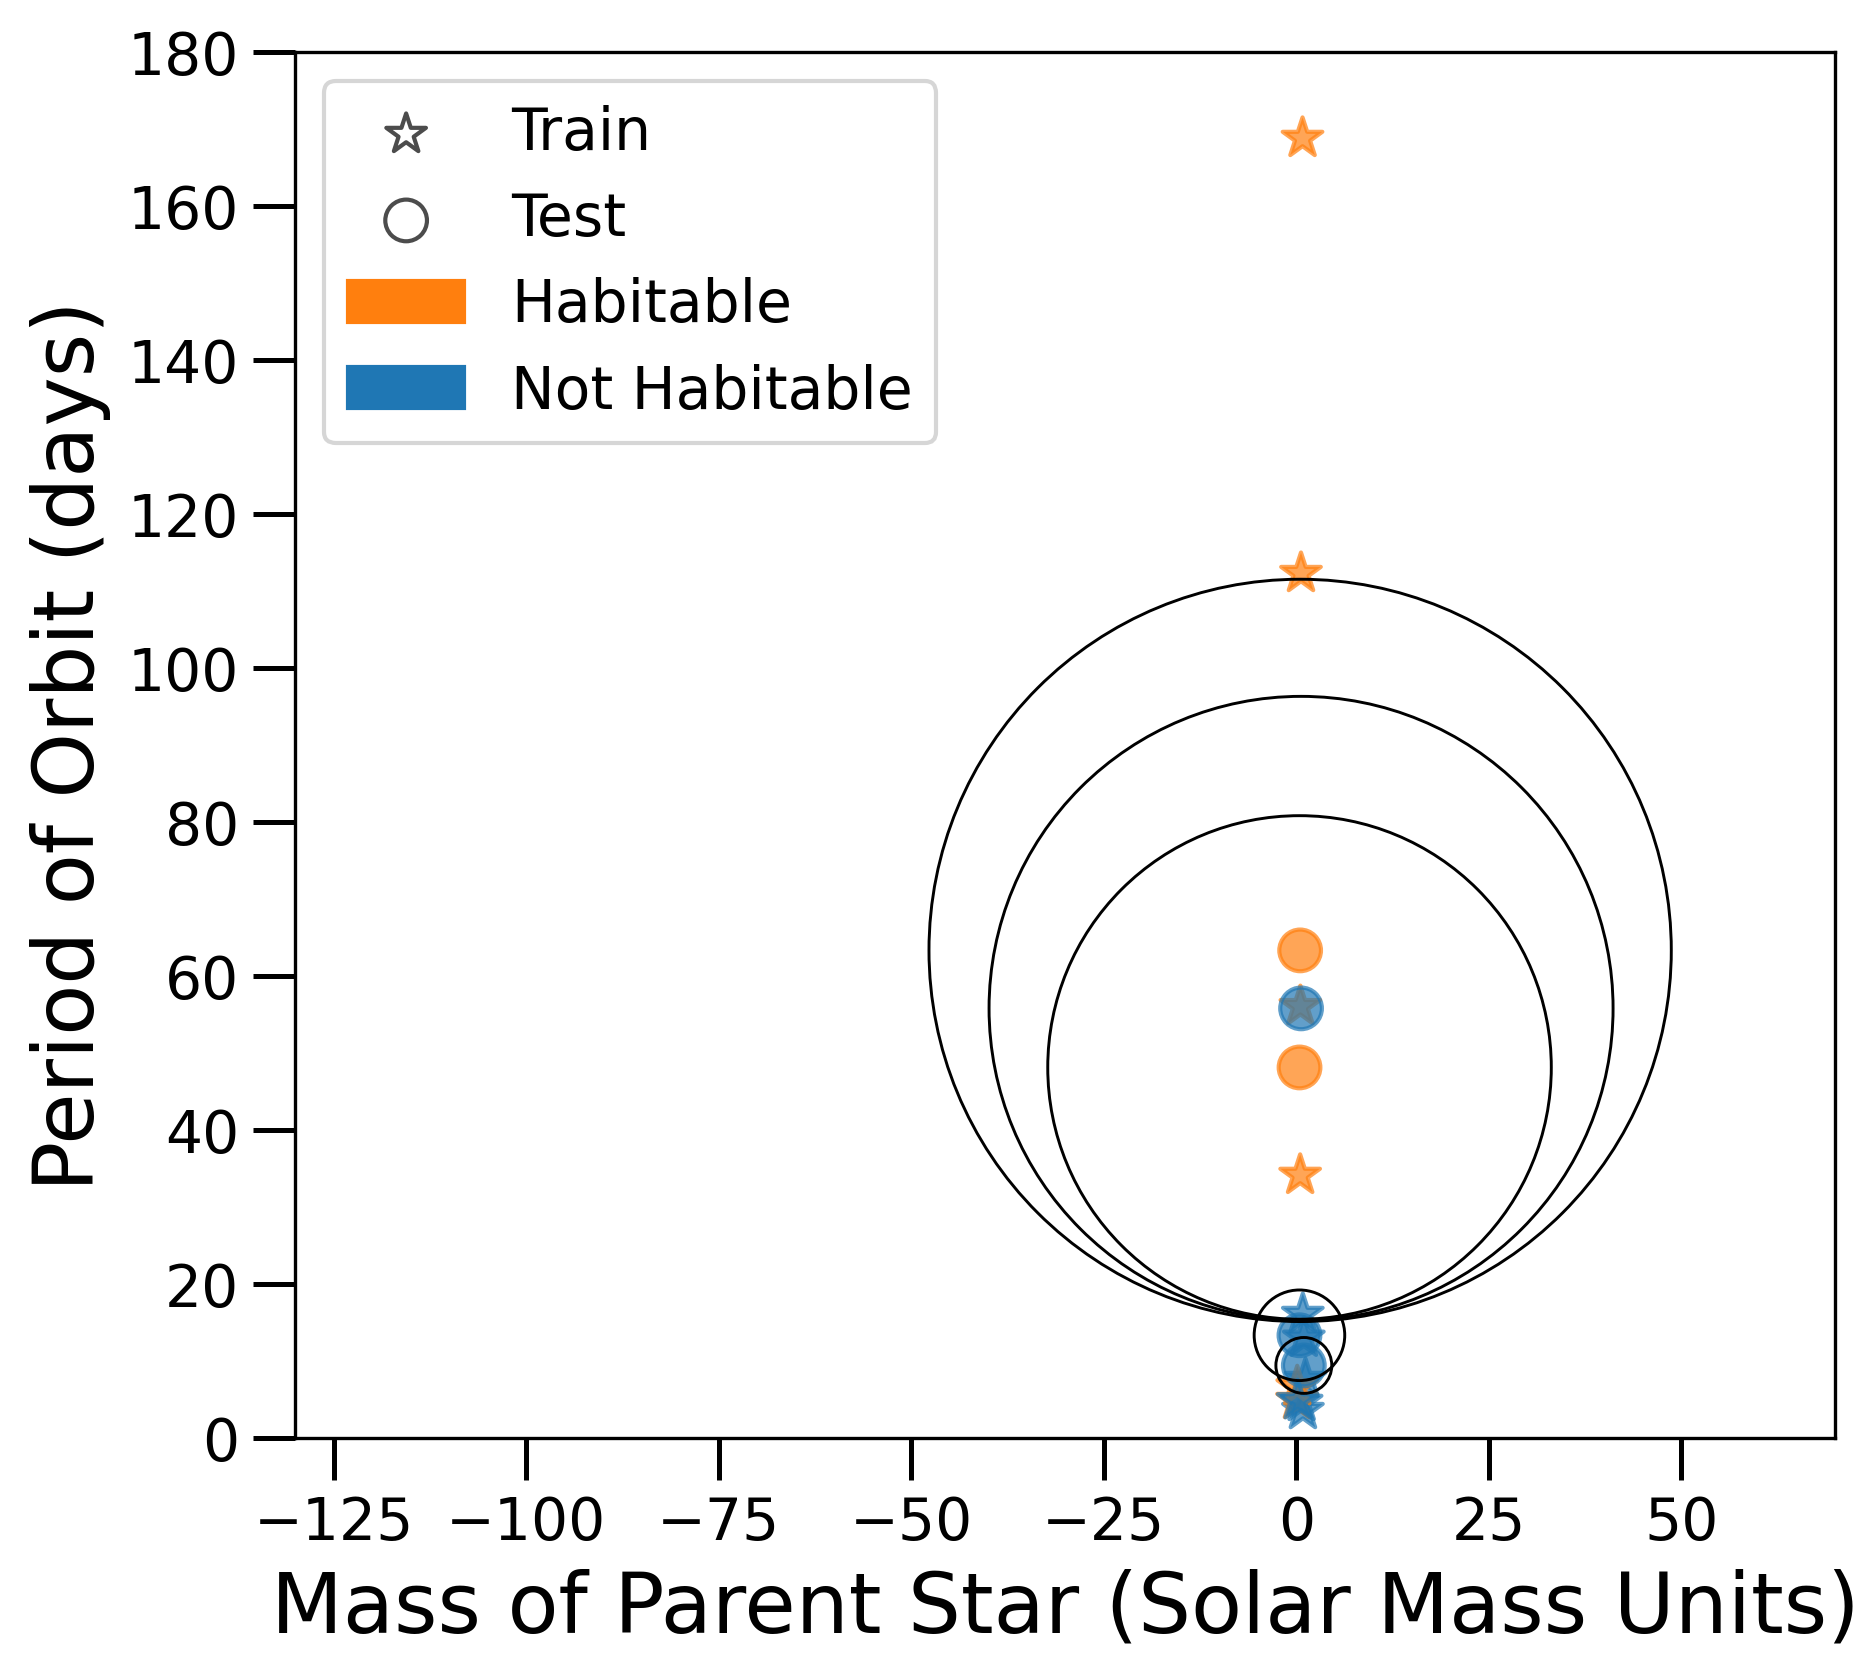

In [140]:
fig2 = plt.figure(figsize=(10,6))
#cmap = matplotlib.colors.LinearSegmentedColormap.from_list("", ['#20B2AA','#FF00FF'])
cmap = matplotlib.colors.LinearSegmentedColormap.from_list("", ['C0','C1']) 
a = plt.scatter(TrainSet['S_MASS'], TrainSet['P_PERIOD'], marker = '*',facecolor = 'none',\
            c = TrainSet['P_HABITABLE'], s = 100, label = 'Train', cmap=cmap, alpha=0.7) 
#a.set_facecolor('none') # the marker edge outlines are not working, but we can deal with overlap by alpha < 1 transparency
a = plt.scatter(TestSet['S_MASS'], TestSet['P_PERIOD'], marker = 'o',facecolors = 'none',\
            c = TestSet['P_HABITABLE'], s = 100, label = 'Test', cmap=cmap, alpha=0.7) 
#a.set_facecolor('none')

for i in range(len(TestSet)): #plot neighbors
    circle1=plt.Circle((TestSet['S_MASS'].iloc[i],TestSet['P_PERIOD'].iloc[i]),1.02*knnmodel.kneighbors(Xtest.iloc[:,:2])[0][i,2],\
                       lw = 0.7, edgecolor='k',facecolor='none')
    # increased circle sizes by 2% to make it easier to see 3rd neighbors
    plt.gca().add_artist(circle1)
    
plt.gca().set_aspect(1) # why?
#bluepatch = mpatches.Patch(color='#20B2AA', label='Not Habitable')
#magentapatch = mpatches.Patch(color='#FF00FF', label='Habitable')
bluepatch = mpatches.Patch(color='C0', label='Not Habitable')
orangepatch = mpatches.Patch(color='C1', label='Habitable')
plt.legend();
ax = plt.gca()
leg = ax.get_legend()
leg.legend_handles[0].set_color('k')
leg.legend_handles[0].set_facecolor('none')
leg.legend_handles[1].set_color('k')
leg.legend_handles[1].set_facecolor('none')
plt.legend(handles=[leg.legend_handles[0],leg.legend_handles[1], orangepatch, bluepatch],\
           loc = 'upper left', fontsize = 14)
plt.xlim(-130,70)
plt.ylim(0,180)
plt.xlabel('Mass of Parent Star (Solar Mass Units)')
plt.ylabel('Period of Orbit (days)');
#plt.savefig('HabPlanetsKNN_fig2.png', dpi = 300)

### Do you notice any issue here?

<>:3: SyntaxWarning: "\o" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\o"? A raw string is also an option.
<>:3: SyntaxWarning: "\o" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\o"? A raw string is also an option.
C:\Users\Simon Seo\AppData\Local\Temp\ipykernel_28740\318216449.py:3: SyntaxWarning: "\o" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\o"? A raw string is also an option.
  plt.xlabel('star mass [$M_\odot$]',fontsize=15)


Text(0, 0.5, '$N$')

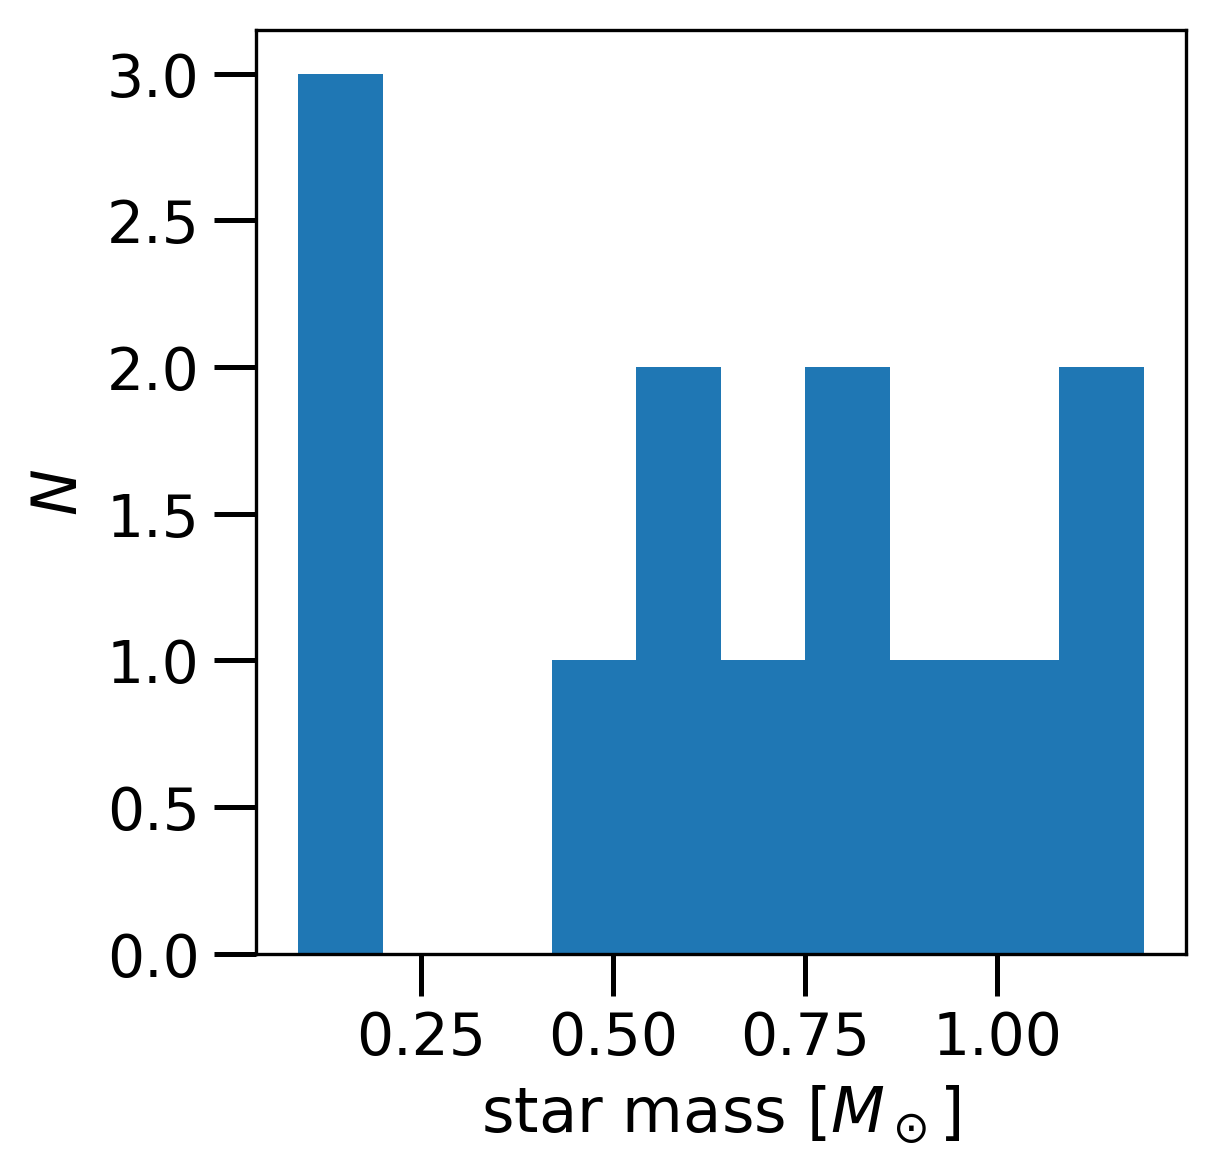

In [141]:
fig3 = plt.figure(figsize=(4,4))
plt.hist(Xtrain.iloc[:,0])#,bins='auto')
plt.xlabel('star mass [$M_\odot$]',fontsize=15)
plt.ylabel('$N$',fontsize=15)

Text(0, 0.5, '$N$')

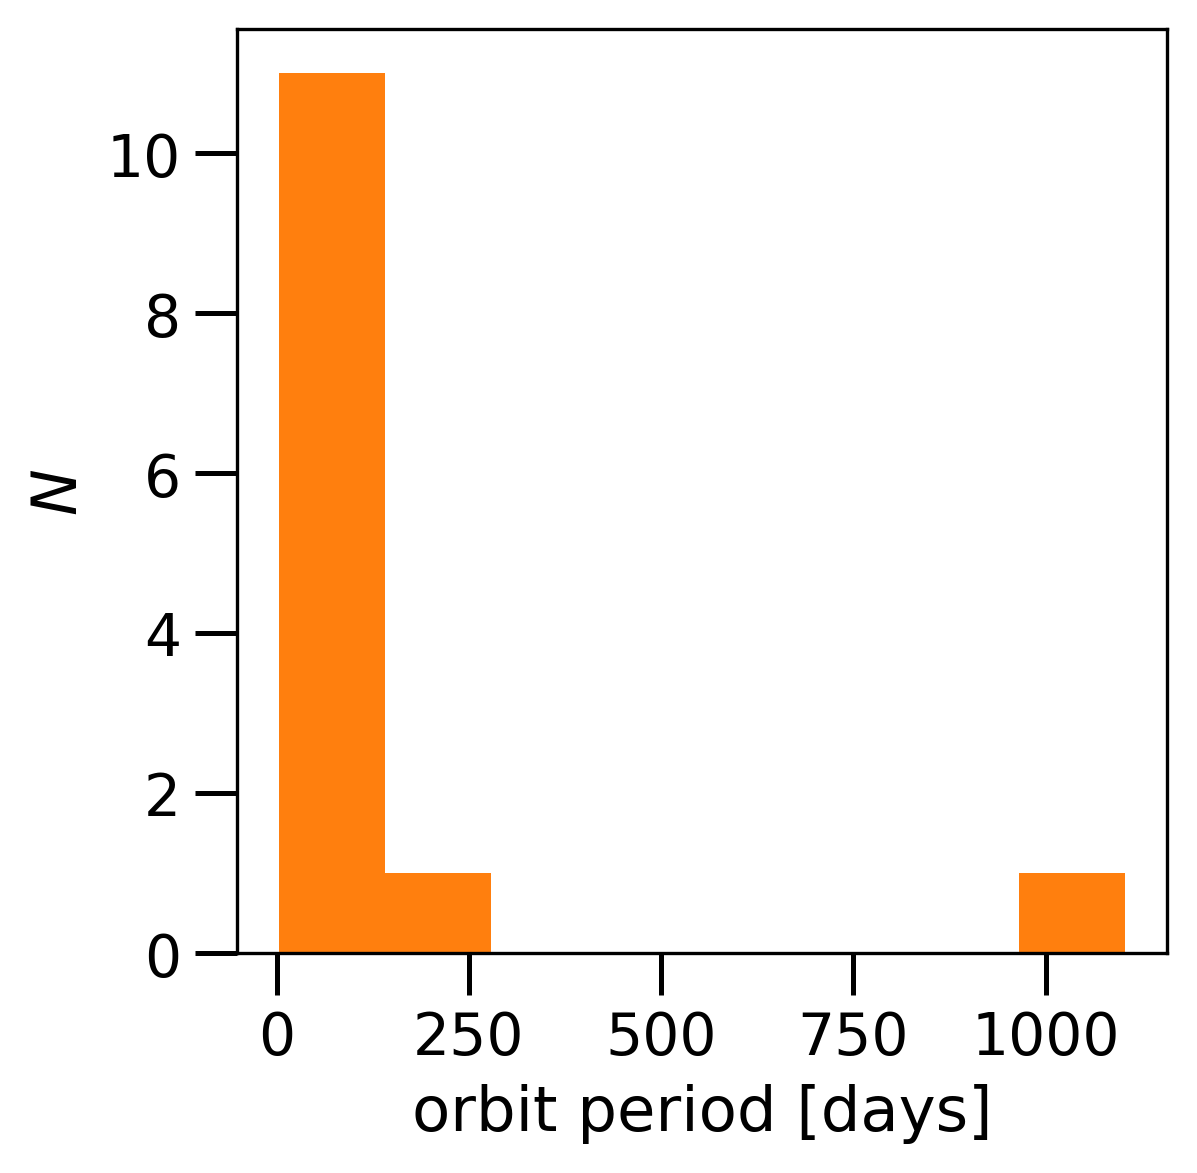

In [142]:
fig4 = plt.figure(figsize=(4,4))
plt.hist(Xtrain.iloc[:,1],color='C1',bins='auto')
plt.xlabel('orbit period [days]',fontsize=15)
plt.ylabel('$N$',fontsize=15)

### If one dimension has a much bigger range than others, it will dominate the decision process. This issue can be solved by <b>scaling</b>. Scaling is a very important pre-processing step for most ML algorithms.

See some examples of different scaling algorithms [here](https://scikit-learn.org/stable/auto_examples/preprocessing/plot_all_scaling.html).

We will go with RobustScaler, which is more resistant to outliers than the standard version.  

In [143]:
#scaler = sklearn.preprocessing.StandardScaler()
scaler = sklearn.preprocessing.RobustScaler()

In [144]:
scaler.fit(Xtrain) # important: we only scale the train set.

,"with_centering with_centering: bool, default=TrueIf `True`, center the data before scaling.This will cause :meth:`transform` to raise an exception when attemptedon sparse matrices, because centering them entails building a densematrix which in common use cases is likely to be too large to fit inmemory.",True
,"with_scaling with_scaling: bool, default=TrueIf `True`, scale the data to interquartile range.",True
,"quantile_range quantile_range: tuple (q_min, q_max), 0.0 < q_min < q_max < 100.0, default=(25.0, 75.0)Quantile range used to calculate `scale_`. By default this is equal tothe IQR, i.e., `q_min` is the first quantile and `q_max` is the thirdquantile... versionadded:: 0.18","(25.0, ...)"
,"copy copy: bool, default=TrueIf `False`, try to avoid a copy and do inplace scaling instead.This is not guaranteed to always work inplace; e.g. if the data isnot a NumPy array or scipy.sparse CSR matrix, a copy may still bereturned.",True
,"unit_variance unit_variance: bool, default=FalseIf `True`, scale data so that normally distributed features have avariance of 1. In general, if the difference between the x-values of`q_max` and `q_min` for a standard normal distribution is greaterthan 1, the dataset will be scaled down. If less than 1, the datasetwill be scaled up... versionadded:: 0.24",False


In [145]:
scaledXtrain = scaler.transform(Xtrain)

In [146]:
scaledXtrain

array([[ 0.47222222, -0.18360363, -0.33840183],
       [ 0.44444444,  0.06038761,  0.05671512],
       [ 1.38888889, -0.10467304, -0.14339694],
       [-0.22222222,  1.94175736,  1.60417741],
       [ 0.80555556,  0.        ,  0.        ],
       [-1.66666667, -0.15801948, -0.43679409],
       [ 0.        , -0.16299717, -0.31519247],
       [-1.58333333, -0.12323674, -0.38472405],
       [ 1.19444444, 21.311672  , 11.01745224],
       [ 0.33333333,  3.04655169,  2.38937206],
       [-0.52777778,  0.41352236,  0.3761471 ],
       [-0.44444444,  0.84198052,  0.66159817],
       [-1.41666667, -0.15877753, -0.40201197]])

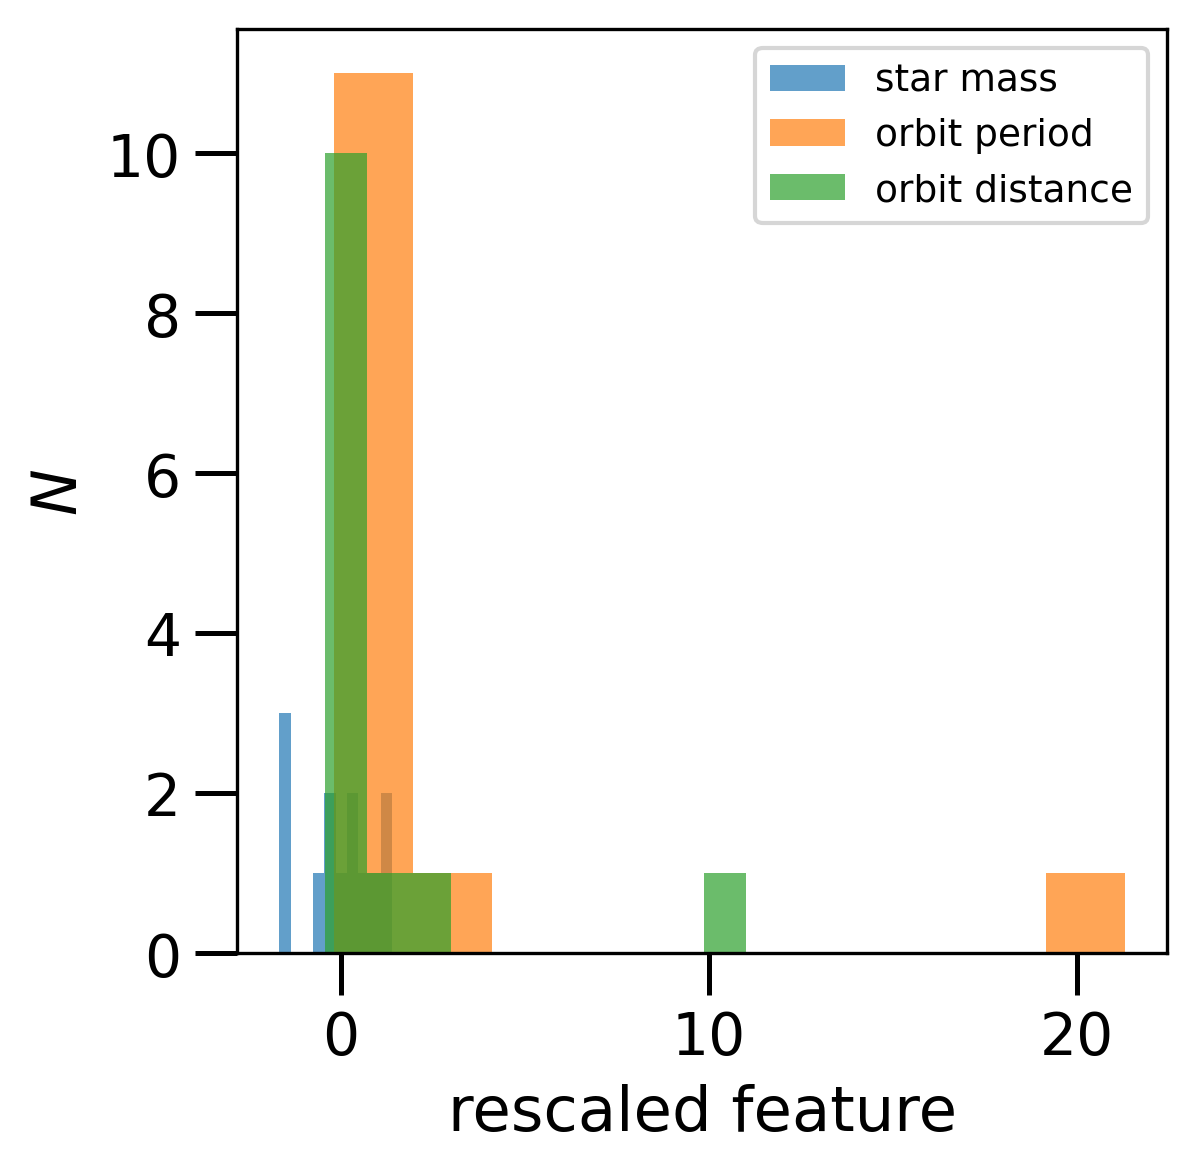

In [147]:
fig5 = plt.figure(figsize=(4,4))
plt.hist(scaledXtrain[:,0],alpha=0.7,label='star mass')
plt.hist(scaledXtrain[:,1],alpha=0.7,label='orbit period')
plt.hist(scaledXtrain[:,2],alpha=0.7,label='orbit distance')
plt.xlabel('rescaled feature',fontsize=15)
plt.ylabel('$N$',fontsize=15)
plt.legend(loc='best',fontsize=9)

In [148]:
scaledXtest = scaler.transform(Xtest) # note that these are now numpy arrays, not data frames

In [149]:
scaler.inverse_transform #This unscales if needed

<bound method RobustScaler.inverse_transform of RobustScaler()>

In [150]:
knnmodel.fit(scaledXtrain[:,:2],ytrain).predict(scaledXtest[:,:2])

array([0, 1, 1, 0, 1])

In [151]:
knnmodel.kneighbors(scaledXtest[:,:2])

(array([[0.2500478 , 0.53900086, 1.00570768, 1.01881597, 1.10501506,
         1.21912386, 1.30411739],
        [0.47721081, 0.66005572, 0.79614695, 0.81602148, 0.89902246,
         0.90408361, 1.22338605],
        [0.16494121, 0.57079985, 1.00501058, 1.26289   , 1.34122004,
         1.44803331, 1.52999489],
        [0.06956397, 0.35230123, 0.38378203, 0.58438893, 0.81095593,
         1.41815027, 1.54706605],
        [0.34256727, 0.35245873, 1.07701084, 1.13365088, 1.16236364,
         1.24679743, 1.34887557]]),
 array([[11, 10,  1,  6,  3,  0,  4],
        [10, 12,  6,  7, 11,  5,  1],
        [11, 10,  3,  6,  1, 12,  7],
        [ 4,  0,  1,  2,  6, 10, 11],
        [11, 10, 12,  6,  7,  5,  1]]))

In [152]:
print(scaledXtrain) # we already did this above?

[[ 0.47222222 -0.18360363 -0.33840183]
 [ 0.44444444  0.06038761  0.05671512]
 [ 1.38888889 -0.10467304 -0.14339694]
 [-0.22222222  1.94175736  1.60417741]
 [ 0.80555556  0.          0.        ]
 [-1.66666667 -0.15801948 -0.43679409]
 [ 0.         -0.16299717 -0.31519247]
 [-1.58333333 -0.12323674 -0.38472405]
 [ 1.19444444 21.311672   11.01745224]
 [ 0.33333333  3.04655169  2.38937206]
 [-0.52777778  0.41352236  0.3761471 ]
 [-0.44444444  0.84198052  0.66159817]
 [-1.41666667 -0.15877753 -0.40201197]]


 ### The distances of neighbors look more balanced and give equal weight to all features:

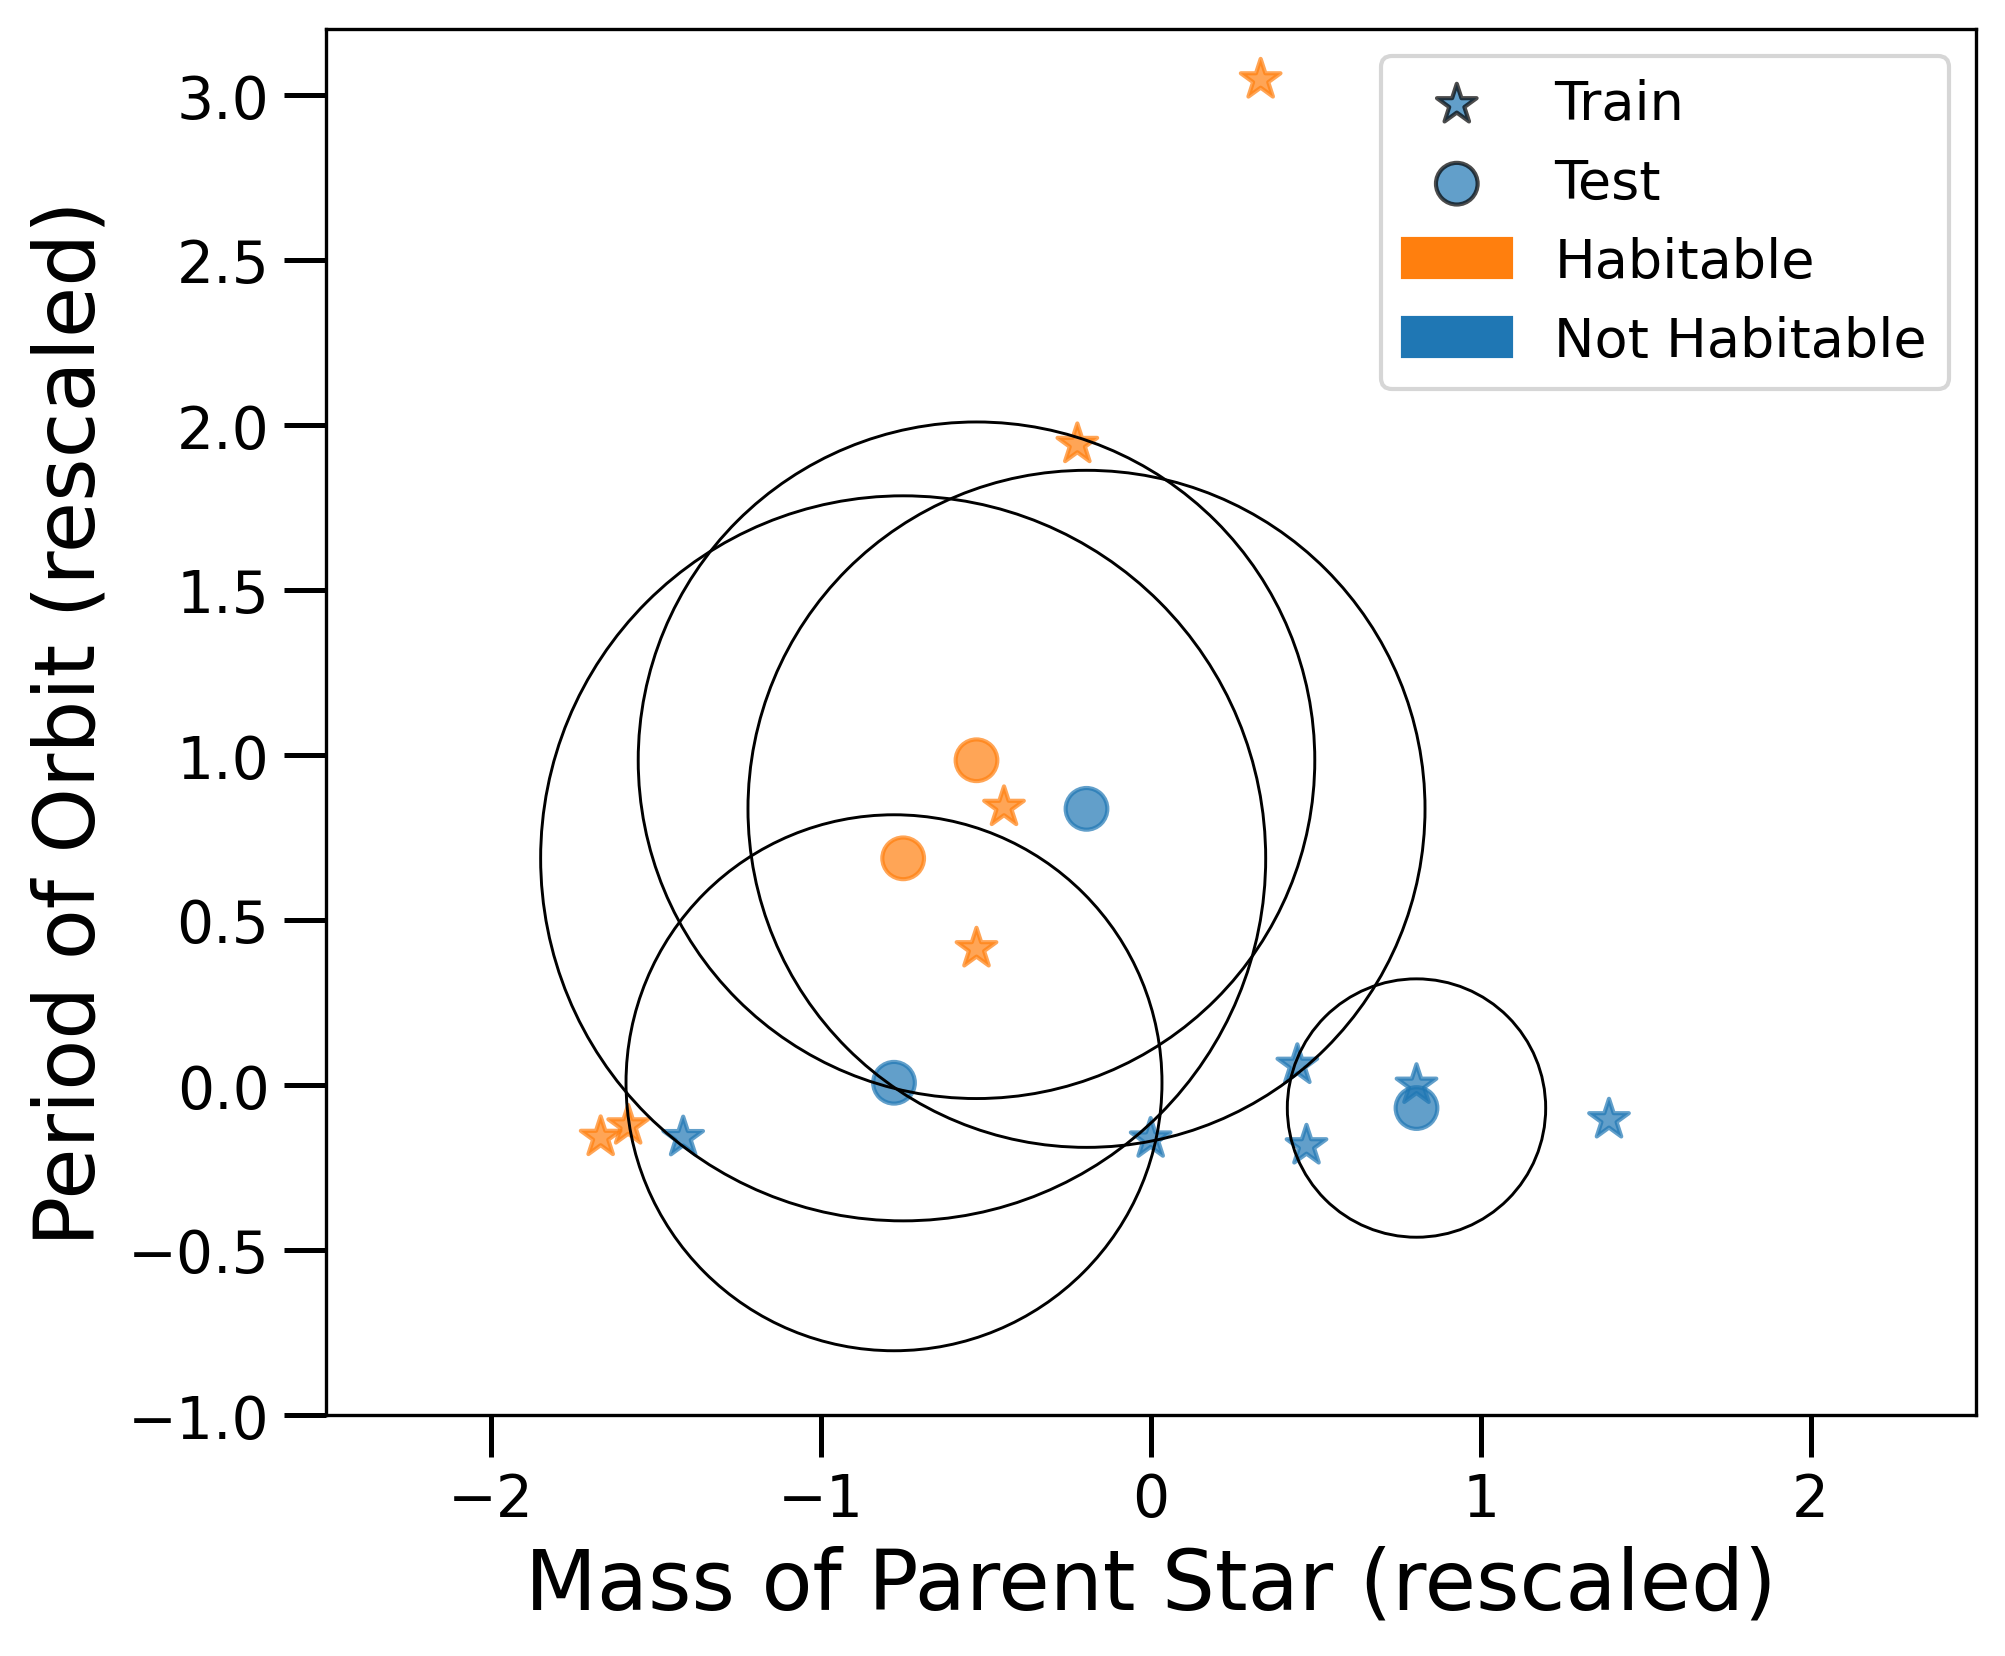

In [153]:
fig6 = plt.figure(figsize=(10,6))#, aspect_ratio = 'equal')
#cmap = matplotlib.colors.LinearSegmentedColormap.from_list("", ['#20B2AA','#FF00FF'])
cmap = matplotlib.colors.LinearSegmentedColormap.from_list("", ['C0','C1'])
plt.scatter(scaledXtrain[:,0], scaledXtrain[:,1], marker = '*',\
            c = ytrain, s = 100, label = 'Train', cmap=cmap, alpha=0.7) #, 
plt.scatter(scaledXtest[:,0], scaledXtest[:,1], marker = 'o',\
            c = ytest, s = 100, label = 'Test', cmap=cmap, alpha=0.7) #label = ,

for i in range(len(TestSet)):
    circle1=plt.Circle((scaledXtest[i,0],scaledXtest[i,1]),1.02*knnmodel.kneighbors(scaledXtest[:,:2])[0][i,2],\
                       edgecolor='k',facecolor='none', lw = 0.7)
    plt.gca().add_artist(circle1)

plt.gca().set_aspect(1)
plt.legend();
ax = plt.gca()
leg = ax.get_legend()
leg.legend_handles[0].set_color('k')
#leg.legendHandles[0].set_facecolor('none')
leg.legend_handles[1].set_color('k')
#leg.legendHandles[1].set_facecolor('none')
plt.legend(handles=[leg.legend_handles[0],leg.legend_handles[1], orangepatch, bluepatch],\
           loc = 'upper right', fontsize = 13)
plt.xlabel('Mass of Parent Star (rescaled)')
plt.ylabel('Period of Orbit (rescaled)');
plt.xlim(-2.5,2.5)
plt.ylim(-1.,3.2);
#plt.savefig('HabPlanetsKNNscaled.png', dpi = 300)

In [154]:
#mat = metrics.confusion_matrix(ytrain, model.predict(scaledXtrain[:,:2]))
mat = metrics.confusion_matrix(ytest, knnmodel.predict(scaledXtest[:,:2]))

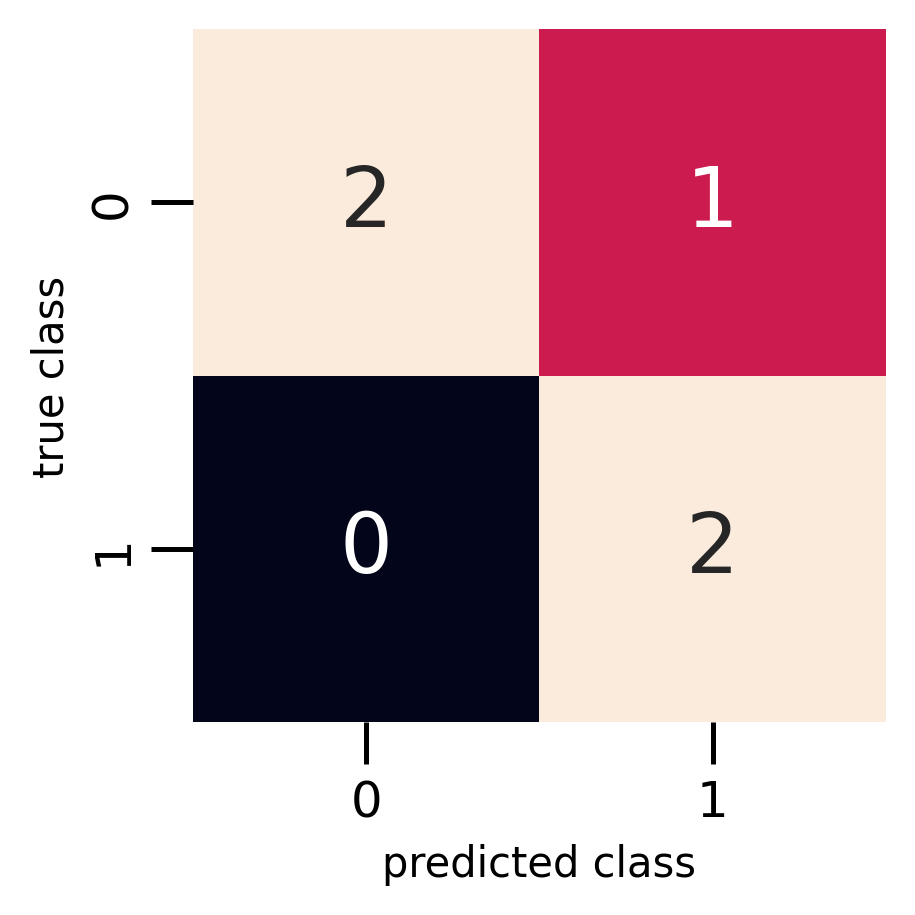

In [155]:
fig7 = plt.figure(figsize=(3,3))
sns.heatmap(mat, square=True, annot=True, cbar=False)
plt.xlabel('predicted class',fontsize=10)
plt.ylabel('true class',fontsize=10)
plt.tick_params(labelsize=12)

2D grid of classification probabilities:

In [156]:
mm, pp = np.meshgrid(np.linspace(-3,3,100), np.linspace(-1,4,100))
prob = knnmodel.predict_proba(np.c_[mm.ravel(), pp.ravel()]) # c_ is similar to column_stack here
prob = prob[:,1].reshape(mm.shape)

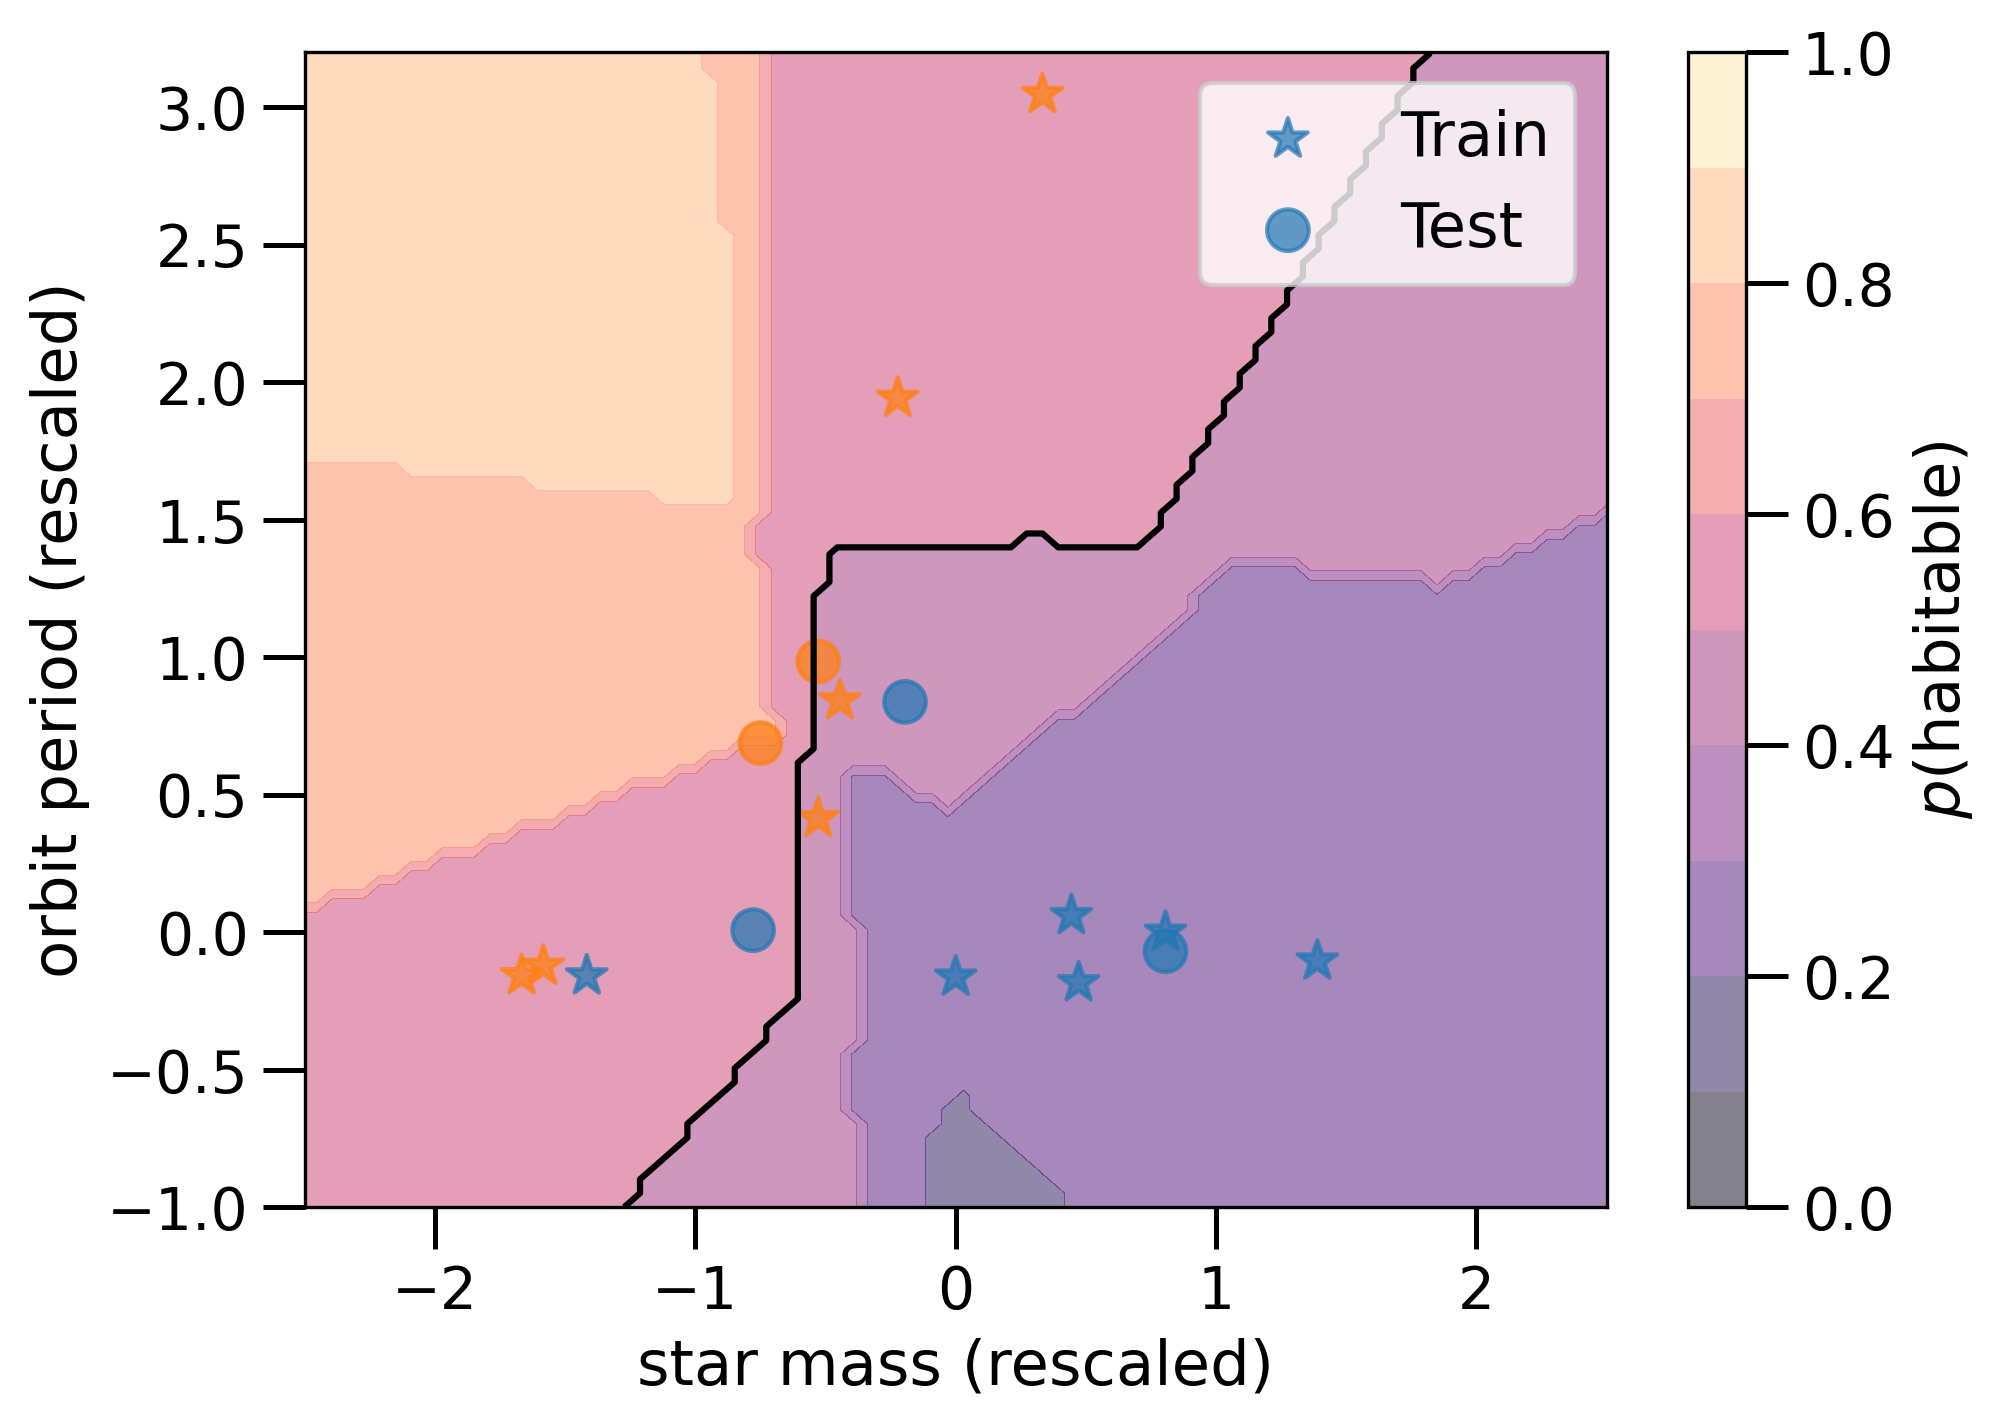

In [157]:
fig8 = plt.figure(figsize=(7,5))
cs=plt.contourf(mm,pp,prob,cmap="magma",levels=np.linspace(0,1,11),alpha=0.5)
cbar = fig8.colorbar(cs)
cbar.set_label('$p$(habitable)',fontsize=15)
plt.contour(mm,pp,prob,[0.5],colors='k')
plt.scatter(scaledXtrain[:,0], scaledXtrain[:,1], marker = '*',\
            c = ytrain, s = 100, label = 'Train', cmap=cmap, alpha=0.7) #, 
plt.scatter(scaledXtest[:,0], scaledXtest[:,1], marker = 'o',\
            c = ytest, s = 100, label = 'Test', cmap=cmap, alpha=0.7)
#plt.plot(LearningSet1['S_MASS'].iloc[habi],np.log10(LearningSet1['P_DISTANCE'].iloc[habi]),'o',c='C1',ms=10,alpha=0.7,label='habitable')
#plt.plot(LearningSet1['S_MASS'].iloc[nohabi],np.log10(LearningSet1['P_DISTANCE'].iloc[nohabi]),'o',c='C0',ms=10,alpha=0.7,label='not habitable')
plt.xlabel('star mass (rescaled)',fontsize=15)
plt.ylabel('orbit period (rescaled)',fontsize=15)
plt.legend(loc='best',fontsize=15)
plt.xlim(-2.5,2.5)
plt.ylim(-1.,3.2);

### Note: for the purpose of application (not visualization), we should use all three features.

### Discussion questions:
    
We discovered that kNN needs scaling! Does DT have the same issue?

Any thoughts on strengths/weaknesses?

Changed Parameters.